# 00 — Homogenización de Datos · P8-Data-Analyst
**Bootcamp IA P4 · Factoría F5 Madrid**  
**Python:** 3.13 · **Fuente:** CSV de 6 ciudades AirBnB  
**Repositorio:** https://github.com/Jose-JulioRamirezySanchez-Escobar/P8-Data-Analyst

---

## Objetivo

Transformar los 6 datasets CSV en un único dataset limpio, homogéneo y comparable.  
Este notebook debe ejecutarse **antes** del EDA. Su salida es `data/processed/airbnb_homogenizado.csv`.

## Fases
1. Carga y auditoría inicial
2. Detección y traducción de caracteres japoneses (Tokio)
3. Validación y conversión de coordenadas geográficas
4. Conversión de monedas a EUR
5. Normalización de fechas
6. Eliminación de duplicados e imputación de nulos
7. Selección de campos comunes y significativos
8. Guardado del dataset homogenizado

> **[SDD — Spec-Driven Development]**  
> Cada sección incluye especificaciones que describen qué debe hacer el código, por qué, y qué criterio de la rúbrica cubre.  
> Todas las decisiones de transformación quedan documentadas en este notebook.

## 0. Imports y configuración

In [1]:
# SDD: Imports — todas las dependencias declaradas al inicio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
import re
import os
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)

# Tipo de cambio a EUR — fecha de referencia fija para reproducibilidad
# Fuente: Banco Central Europeo
FECHA_REFERENCIA_CAMBIO = '2025-01-01'
TIPOS_CAMBIO_EUR = {
    'EUR': 1.0,      # Madrid, Milán
    'GBP': 1.21,     # Londres  (1 GBP = 1.21 EUR aprox.)
    'USD': 0.92,     # Nueva York (1 USD = 0.92 EUR aprox.)
    'AUD': 0.59,     # Sydney  (1 AUD = 0.59 EUR aprox.)
    'JPY': 0.0061,   # Tokio   (1 JPY = 0.0061 EUR aprox.)
}

# Bounding boxes geográficos por ciudad (lat_min, lat_max, lon_min, lon_max)
BOUNDING_BOXES = {
    'Madrid':   (40.30, 40.65, -3.85, -3.52),
    'London':   (51.28, 51.70, -0.51,  0.33),
    'Milan':    (45.38, 45.54,  9.04,  9.28),
    'New York': (40.48, 40.92, -74.26,-73.68),
    'Sydney':   (-34.17,-33.57,150.52,151.35),
    'Tokyo':    (35.52, 35.82, 139.56,139.92),
}

print('✅ Configuración cargada')
print(f'   Fecha referencia tipo de cambio: {FECHA_REFERENCIA_CAMBIO}')
print(f'   Ciudades configuradas: {list(BOUNDING_BOXES.keys())}')

✅ Configuración cargada
   Fecha referencia tipo de cambio: 2025-01-01
   Ciudades configuradas: ['Madrid', 'London', 'Milan', 'New York', 'Sydney', 'Tokyo']


---
## 1. Carga y auditoría inicial

> **[SDD]** Cargar los 6 CSV sin modificar nada. Generar un informe de auditoría por dataset que documente: forma, tipos de datos, nulos y columnas disponibles. Este informe es la línea base de todas las decisiones posteriores.

**¿Por qué cargar sin modificar primero?**  
Para entender exactamente qué tenemos antes de transformar. Cualquier decisión de limpieza debe basarse en evidencia del dato crudo, no en suposiciones.

In [2]:
# SDD: Carga de CSVs crudos — Rúbrica: Uso y gestión de formato .csv

BASE_URL = 'https://raw.githubusercontent.com/Jose-JulioRamirezySanchez-Escobar/P8-Data-Analyst/main/data/raw/'

DATASETS = {
    'New York': {'file': 'NY_airbnb.csv',     'moneda': 'USD', 'encoding': 'utf-8'},
    'Madrid':   {'file': 'madrid_airbnb.csv', 'moneda': 'EUR', 'encoding': 'utf-8'},
    'Tokyo':    {'file': 'tokyo_airbnb.csv',  'moneda': 'JPY', 'encoding': 'utf-8'},
    'Sydney':   {'file': 'sydney_airbnb.csv', 'moneda': 'AUD', 'encoding': 'utf-8'},
    'London':   {'file': 'london_airbnb.csv', 'moneda': 'GBP', 'encoding': 'utf-8'},
    'Milan':    {'file': 'milan_airbnb.csv',  'moneda': 'EUR', 'encoding': 'utf-8'},
}

dfs_raw = {}
for ciudad, meta in DATASETS.items():
    url = BASE_URL + meta['file']
    try:
        df = pd.read_csv(url, encoding=meta['encoding'], low_memory=False)
        df['city'] = ciudad
        df['moneda_origen'] = meta['moneda']
        dfs_raw[ciudad] = df
        print(f'✅ {ciudad:12} → {df.shape[0]:>6,} filas × {df.shape[1]:>2} columnas')
    except Exception as e:
        print(f'❌ {ciudad}: {e}')

print(f'\nTotal datasets cargados: {len(dfs_raw)}/6')

✅ New York     → 48,895 filas × 18 columnas
✅ Madrid       → 19,618 filas × 18 columnas
✅ Tokyo        → 11,466 filas × 16 columnas
✅ Sydney       → 36,662 filas × 18 columnas
✅ London       → 85,068 filas × 18 columnas
✅ Milan        → 18,322 filas × 17 columnas

Total datasets cargados: 6/6


In [3]:
# SDD: Informe de auditoría — columnas disponibles por ciudad

print('=== MATRIZ DE COLUMNAS POR CIUDAD ===')
print()

# Recopilar todas las columnas
todas_cols = set()
for df in dfs_raw.values():
    todas_cols.update(df.columns)
todas_cols = sorted(todas_cols - {'city', 'moneda_origen'})

# Crear matriz de presencia
matriz = pd.DataFrame(index=todas_cols, columns=list(dfs_raw.keys()))
for ciudad, df in dfs_raw.items():
    for col in todas_cols:
        matriz.loc[col, ciudad] = '✅' if col in df.columns else '❌'

print(matriz.to_string())
print()

# Columnas comunes a TODOS los datasets
cols_comunes = [col for col in todas_cols
                if all(col in df.columns for df in dfs_raw.values())]
print(f'Columnas presentes en TODOS los datasets ({len(cols_comunes)}):')
print(cols_comunes)

=== MATRIZ DE COLUMNAS POR CIUDAD ===

                               New York Madrid Tokyo Sydney London Milan
availability_365                      ✅      ✅     ❌      ✅      ✅     ✅
calculated_host_listings_count        ✅      ✅     ❌      ✅      ✅     ✅
host_id                               ✅      ✅     ✅      ✅      ✅     ✅
host_name                             ✅      ✅     ✅      ✅      ✅     ✅
id                                    ✅      ✅     ✅      ✅      ✅     ✅
last_review                           ✅      ✅     ✅      ✅      ✅     ✅
latitude                              ✅      ✅     ✅      ✅      ✅     ✅
longitude                             ✅      ✅     ✅      ✅      ✅     ✅
minimum_nights                        ✅      ✅     ✅      ✅      ✅     ✅
name                                  ✅      ✅     ✅      ✅      ✅     ✅
neighbourhood                         ✅      ✅     ✅      ✅      ✅     ✅
neighbourhood_group                   ✅      ✅     ✅      ✅      ✅     ❌
number_of_re

In [4]:
# SDD: Auditoría de nulos por ciudad

print('=== NULOS POR CIUDAD Y COLUMNA ===')
print()
for ciudad, df in dfs_raw.items():
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    if len(nulos) > 0:
        print(f'--- {ciudad} ---')
        for col, n in nulos.items():
            pct = n / len(df) * 100
            print(f'  {col:40} {n:>5} ({pct:.1f}%)')
        print()

=== NULOS POR CIUDAD Y COLUMNA ===

--- New York ---
  name                                        16 (0.0%)
  host_name                                   21 (0.0%)
  last_review                              10052 (20.6%)
  reviews_per_month                        10052 (20.6%)

--- Madrid ---
  name                                         3 (0.0%)
  host_name                                  527 (2.7%)
  last_review                               5637 (28.7%)
  reviews_per_month                         5637 (28.7%)

--- Tokyo ---
  host_name                                   16 (0.1%)
  neighbourhood_group                      11466 (100.0%)
  last_review                               1677 (14.6%)
  reviews_per_month                         1677 (14.6%)

--- Sydney ---
  name                                        12 (0.0%)
  host_name                                    6 (0.0%)
  neighbourhood_group                      36662 (100.0%)
  last_review                              11937 (

---
## 2. Detección y traducción de caracteres japoneses (Tokio)

> **[SDD]** Detectar en el dataset de Tokio las columnas que contienen caracteres en rango Unicode japonés (hiragana U+3040–U+309F, katakana U+30A0–U+30FF, kanji U+4E00–U+9FFF). Confirmar que son japonés. Crear columnas transliteradas paralelas para las columnas afectadas (`name`, `host_name`, `neighbourhood`).

**¿Por qué transliterar y no eliminar?**  
Eliminando se pierde información. Transliterando se mantiene el dato original y se añade una versión comparable con el resto de ciudades. Es la práctica estándar en análisis multilingüe.

In [5]:
# SDD: Detección de caracteres japoneses — Rúbrica: Limpieza y preprocesado de datos

def contiene_japones(texto):
    """Detecta si un string contiene caracteres japoneses."""
    if not isinstance(texto, str):
        return False
    for char in texto:
        cp = ord(char)
        # Hiragana, Katakana, CJK Unified Ideographs (kanji)
        if (0x3040 <= cp <= 0x309F or   # Hiragana
            0x30A0 <= cp <= 0x30FF or   # Katakana
            0x4E00 <= cp <= 0x9FFF):    # Kanji
            return True
    return False

df_tokyo = dfs_raw['Tokyo'].copy()

print('=== ANÁLISIS DE CARACTERES JAPONESES EN TOKIO ===')
print()
cols_texto = ['name', 'host_name', 'neighbourhood']
for col in cols_texto:
    if col in df_tokyo.columns:
        n_japones = df_tokyo[col].apply(contiene_japones).sum()
        pct = n_japones / len(df_tokyo) * 100
        print(f'  {col:20}: {n_japones:>5} filas con japonés ({pct:.1f}%)')

print()
print('Ejemplos de nombres con caracteres japoneses:')
mask_jp = df_tokyo['name'].apply(contiene_japones)
print(df_tokyo[mask_jp]['name'].head(5).to_string())

=== ANÁLISIS DE CARACTERES JAPONESES EN TOKIO ===

  name                :  2121 filas con japonés (18.5%)
  host_name           :  1318 filas con japonés (11.5%)
  neighbourhood       :     0 filas con japonés (0.0%)

Ejemplos de nombres con caracteres japoneses:
52                                        東京下町生活
58                         ※定期借家契約限定!新宿駅13分!2BRs
65                          ｱｼﾞｱﾝﾐｯｸｽﾃｲｽﾄの癒される空間
69    Tatoo ok! Onsen of 400 years of history【禅】
74             Tatoo ok! TOKYO♨ONSEN and ROOM【寿】


In [6]:
# SDD: Transliteración de caracteres japoneses
# Estrategia: usar la librería 'pykakasi' si está disponible,
# si no, usar transliteración Unicode básica como fallback.

def transliterar_texto(texto):
    """Transliteración básica: elimina caracteres no-ASCII y normaliza."""
    if not isinstance(texto, str):
        return texto
    # Normalización NFKD + eliminación de caracteres no-ASCII
    normalizado = unicodedata.normalize('NFKD', texto)
    ascii_text = normalizado.encode('ascii', 'ignore').decode('ascii')
    # Si queda vacío (todo era japonés), devolver indicador
    resultado = ascii_text.strip()
    return resultado if resultado else '[JP]'

# Intentar usar pykakasi para transliteración más precisa
try:
    import pykakasi
    kks = pykakasi.Kakasi()

    def transliterar_kakasi(texto):
        if not isinstance(texto, str) or not contiene_japones(texto):
            return texto
        result = kks.convert(texto)
        return ' '.join([item['hepburn'] for item in result])

    funcion_translit = transliterar_kakasi
    print('✅ Usando pykakasi para transliteración precisa (romaji)')

except ImportError:
    funcion_translit = transliterar_texto
    print('⚠️  pykakasi no instalado — usando transliteración Unicode básica')
    print('   Para transliteración precisa: uv add pykakasi')

# Aplicar transliteración a columnas afectadas
for col in cols_texto:
    if col in df_tokyo.columns:
        df_tokyo[f'{col}_latin'] = df_tokyo[col].apply(
            lambda x: funcion_translit(x) if contiene_japones(str(x)) else x
        )

print()
print('Ejemplos tras transliteración:')
mask_jp = df_tokyo['name'].apply(contiene_japones)
print(df_tokyo[mask_jp][['name', 'name_latin']].head(5).to_string())

# Actualizar el dataset de Tokio en el diccionario
dfs_raw['Tokyo'] = df_tokyo

✅ Usando pykakasi para transliteración precisa (romaji)

Ejemplos tras transliteración:
                                          name                                                  name_latin
52                                      東京下町生活                                  toukyoushitamachi seikatsu
58                       ※定期借家契約限定!新宿駅13分!2BRs  ※ teiki shakuya keiyaku gentei ! shinjukueki 13 fun ! 2BRs
65                        ｱｼﾞｱﾝﾐｯｸｽﾃｲｽﾄの癒される空間                    ajianmikkusuteisuto no iyasa reru kuukan
69  Tatoo ok! Onsen of 400 years of history【禅】           Tatoo ok !  Onsen of 400 years of history ( zen )
74           Tatoo ok! TOKYO♨ONSEN and ROOM【寿】              Tatoo ok !  TOKYO ♨ ONSEN and ROOM ( hisashi )


---
## 3. Validación y conversión de coordenadas geográficas

> **[SDD]** Verificar que `latitude` y `longitude` son de tipo float y que sus valores corresponden geográficamente a la ciudad declarada. Marcar como **dato atípico geográfico** cualquier registro cuyas coordenadas estén fuera del bounding box de la ciudad.

**Distinción importante:**  
- **Dato atípico:** coordenada con tipo incorrecto (string, NaN, símbolo) → problema de formato  
- **Outlier geográfico:** coordenada con tipo correcto pero fuera del área de la ciudad → valor anómalo  

**¿Por qué validar coordenadas?**  
Un alojamiento en "Madrid" con coordenadas en el Pacífico es un error de datos que contaminaría cualquier visualización geográfica y el análisis de precios por zona.

In [7]:
# SDD: Validación de coordenadas — Rúbrica: Técnicas avanzadas de limpieza de datos

def validar_coordenadas(df, ciudad):
    """Convierte lat/lon a float y valida contra el bounding box de la ciudad."""
    df = df.copy()
    bbox = BOUNDING_BOXES[ciudad]
    lat_min, lat_max, lon_min, lon_max = bbox

    # Convertir a numérico (errores → NaN)
    df['latitude']  = pd.to_numeric(df['latitude'],  errors='coerce')
    df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

    # Detectar NaN tras conversión (eran datos atípicos de tipo)
    n_lat_nan = df['latitude'].isna().sum()
    n_lon_nan = df['longitude'].isna().sum()

    # Detectar outliers geográficos (fuera del bounding box)
    fuera_bbox = (
        (df['latitude']  < lat_min) | (df['latitude']  > lat_max) |
        (df['longitude'] < lon_min) | (df['longitude'] > lon_max)
    ) & df['latitude'].notna() & df['longitude'].notna()

    df['geo_fuera_bbox'] = fuera_bbox

    print(f'  {ciudad:12}: NaN lat={n_lat_nan}, lon={n_lon_nan} | '
          f'Fuera bbox={fuera_bbox.sum()} ({fuera_bbox.sum()/len(df)*100:.1f}%)')

    return df

print('=== VALIDACIÓN DE COORDENADAS ===')
print()
for ciudad in dfs_raw:
    dfs_raw[ciudad] = validar_coordenadas(dfs_raw[ciudad], ciudad)

=== VALIDACIÓN DE COORDENADAS ===

  New York    : NaN lat=0, lon=0 | Fuera bbox=0 (0.0%)
  Madrid      : NaN lat=0, lon=0 | Fuera bbox=1 (0.0%)
  Tokyo       : NaN lat=0, lon=0 | Fuera bbox=248 (2.2%)
  Sydney      : NaN lat=0, lon=0 | Fuera bbox=64 (0.2%)
  London      : NaN lat=0, lon=0 | Fuera bbox=0 (0.0%)
  Milan       : NaN lat=0, lon=0 | Fuera bbox=0 (0.0%)


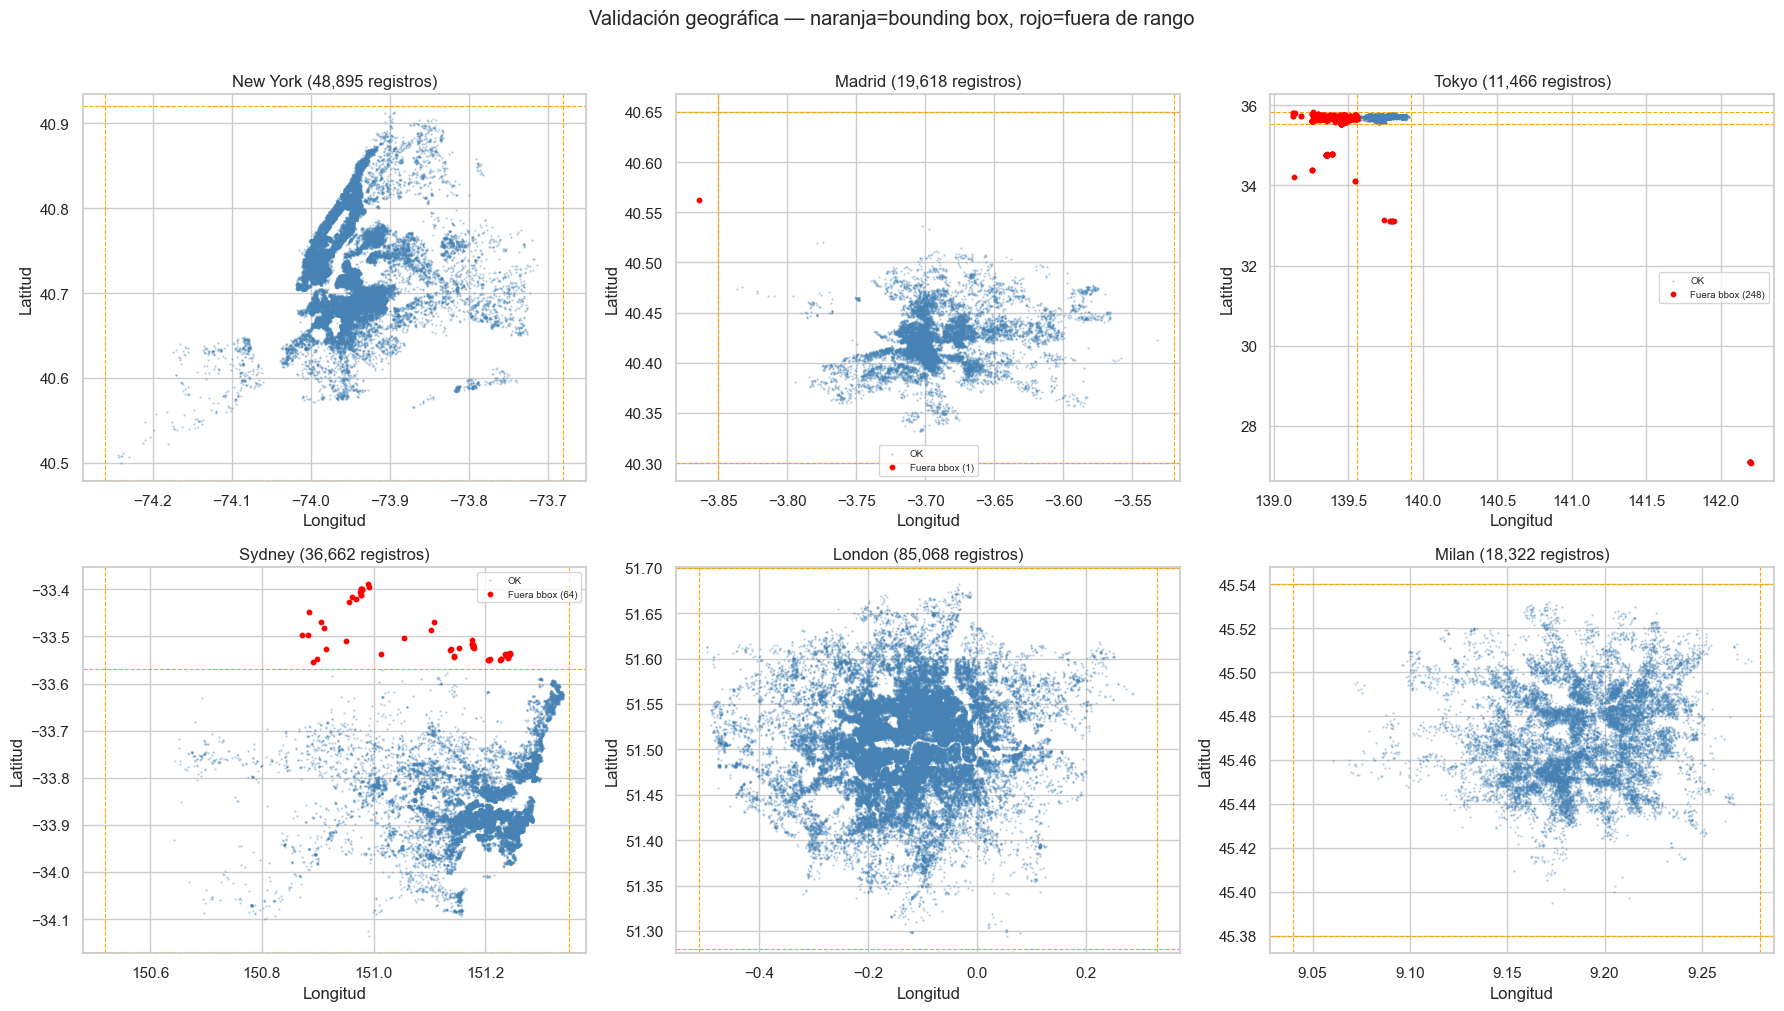

In [8]:
# Visualización de coordenadas para verificar la validación
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (ciudad, df) in enumerate(dfs_raw.items()):
    bbox = BOUNDING_BOXES[ciudad]
    df_ok   = df[~df['geo_fuera_bbox'] & df['latitude'].notna()]
    df_out  = df[ df['geo_fuera_bbox']]

    axes[i].scatter(df_ok['longitude'],  df_ok['latitude'],
                    s=0.5, alpha=0.3, color='steelblue', label='OK')
    if len(df_out) > 0:
        axes[i].scatter(df_out['longitude'], df_out['latitude'],
                        s=10, color='red', label=f'Fuera bbox ({len(df_out)})', zorder=5)

    # Dibujar bounding box
    axes[i].axhline(bbox[0], color='orange', lw=0.8, ls='--')
    axes[i].axhline(bbox[1], color='orange', lw=0.8, ls='--')
    axes[i].axvline(bbox[2], color='orange', lw=0.8, ls='--')
    axes[i].axvline(bbox[3], color='orange', lw=0.8, ls='--')

    axes[i].set_title(f'{ciudad} ({len(df):,} registros)')
    axes[i].set_xlabel('Longitud')
    axes[i].set_ylabel('Latitud')
    if len(df_out) > 0:
        axes[i].legend(fontsize=7)

plt.suptitle('Validación geográfica — naranja=bounding box, rojo=fuera de rango', y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Conversión de monedas a EUR

> **[SDD]** Crear columna `price_eur` con el precio convertido a euros usando tipos de cambio fijos en fecha de referencia `2025-01-01`. Mantener la columna `price` original en moneda local. Documentar la fuente y fecha de los tipos de cambio.

**¿Por qué fecha fija?**  
Los tipos de cambio varían a diario. Usar una fecha fija garantiza que el análisis es reproducible: dos personas ejecutando el notebook en fechas distintas obtienen los mismos resultados. Si se usara el tipo de cambio del día de ejecución, los resultados cambiarían cada día.

**¿Por qué mantener el precio original?**  
El precio en moneda local tiene significado para el mercado local. `price_eur` es para análisis comparativos entre ciudades; `price` es para análisis dentro de una ciudad.

In [9]:
# SDD: Conversión de monedas — Rúbrica: Limpieza y preprocesado de datos

print('=== CONVERSIÓN DE MONEDAS A EUR ===')
print(f'   Fecha referencia: {FECHA_REFERENCIA_CAMBIO}')
print()

for ciudad, df in dfs_raw.items():
    moneda = df['moneda_origen'].iloc[0]
    tasa   = TIPOS_CAMBIO_EUR[moneda]

    # Convertir price a numérico (puede venir como string en algunos datasets)
    df['price'] = pd.to_numeric(
        df['price'].astype(str).str.replace('[^0-9.]', '', regex=True),
        errors='coerce'
    )
    df['price_eur'] = (df['price'] * tasa).round(2)

    precio_medio_local = df['price'].median()
    precio_medio_eur   = df['price_eur'].median()
    print(f'  {ciudad:12}: {moneda} × {tasa} → '
          f'mediana {precio_medio_local:.0f} {moneda} = {precio_medio_eur:.0f} EUR')

    dfs_raw[ciudad] = df

print()
print('✅ Columna price_eur creada en todos los datasets')

=== CONVERSIÓN DE MONEDAS A EUR ===
   Fecha referencia: 2025-01-01

  New York    : USD × 0.92 → mediana 106 USD = 98 EUR
  Madrid      : EUR × 1.0 → mediana 58 EUR = 58 EUR
  Tokyo       : JPY × 0.0061 → mediana 10007 JPY = 61 EUR
  Sydney      : AUD × 0.59 → mediana 136 AUD = 80 EUR
  London      : GBP × 1.21 → mediana 84 GBP = 102 EUR
  Milan       : EUR × 1.0 → mediana 74 EUR = 74 EUR

✅ Columna price_eur creada en todos los datasets


---
## 5. Normalización de fechas

> **[SDD]** Convertir todas las fechas a formato ISO 8601 (`datetime64`). Milán usa formato `dd/mm/yy` — parsear con `dayfirst=True` para evitar inversión de día y mes. Verificar que el rango de fechas es razonable. Marcar como dato atípico cualquier fecha fuera del rango esperado.

**¿Por qué es crítico el formato de Milán?**  
Con el formato `dd/mm/yy`, si se parsea con la configuración por defecto de pandas (`dayfirst=False`), el día 3 del mes 4 se interpretaría como el mes 3 del día 4 — una inversión silenciosa que produce fechas incorrectas sin ningún error visible.

In [10]:
# SDD: Normalización de fechas — Rúbrica: Limpieza y preprocesado de datos

# Configuración de parseo por ciudad
CONFIG_FECHAS = {
    'Milan':    {'dayfirst': True,  'formato': 'dd/mm/yy'},
    'Madrid':   {'dayfirst': False, 'formato': 'yyyy-mm-dd'},
    'London':   {'dayfirst': False, 'formato': 'yyyy-mm-dd'},
    'New York': {'dayfirst': False, 'formato': 'yyyy-mm-dd'},
    'Sydney':   {'dayfirst': False, 'formato': 'yyyy-mm-dd'},
    'Tokyo':    {'dayfirst': False, 'formato': 'yyyy-mm-dd'},
}

RANGO_FECHAS_VALIDO = ('2010-01-01', '2027-01-01')

print('=== NORMALIZACIÓN DE FECHAS ===')
print()

for ciudad, df in dfs_raw.items():
    cfg = CONFIG_FECHAS[ciudad]

    if 'last_review' in df.columns:
        df['last_review'] = pd.to_datetime(
            df['last_review'],
            dayfirst=cfg['dayfirst'],
            errors='coerce'
        )

        n_nulos    = df['last_review'].isna().sum()
        n_total    = len(df)
        fecha_min  = df['last_review'].min()
        fecha_max  = df['last_review'].max()

        # Detectar fechas fuera de rango razonable
        fuera_rango = (
            (df['last_review'] < pd.Timestamp(RANGO_FECHAS_VALIDO[0])) |
            (df['last_review'] > pd.Timestamp(RANGO_FECHAS_VALIDO[1]))
        ) & df['last_review'].notna()

        print(f'  {ciudad:12} [{cfg["formato"]}]:')
        print(f'    Rango: {fecha_min} → {fecha_max}')
        print(f'    Nulos: {n_nulos:,} ({n_nulos/n_total*100:.1f}%) | '
              f'Fuera de rango: {fuera_rango.sum()}')

        dfs_raw[ciudad] = df

print()
print('✅ Fechas normalizadas a datetime64')

=== NORMALIZACIÓN DE FECHAS ===

  New York     [yyyy-mm-dd]:
    Rango: 2011-03-28 00:00:00 → 2019-07-08 00:00:00
    Nulos: 10,052 (20.6%) | Fuera de rango: 0
  Madrid       [yyyy-mm-dd]:
    Rango: 2012-05-28 00:00:00 → 2021-04-17 00:00:00
    Nulos: 5,637 (28.7%) | Fuera de rango: 0
  Tokyo        [yyyy-mm-dd]:
    Rango: 2015-05-25 00:00:00 → 2019-06-27 00:00:00
    Nulos: 1,677 (14.6%) | Fuera de rango: 0
  Sydney       [yyyy-mm-dd]:
    Rango: 2011-11-25 00:00:00 → 2018-12-07 00:00:00
    Nulos: 11,937 (32.6%) | Fuera de rango: 0
  London       [yyyy-mm-dd]:
    Rango: 2011-07-02 00:00:00 → 2019-11-06 00:00:00
    Nulos: 20,006 (23.5%) | Fuera de rango: 0
  Milan        [dd/mm/yy]:
    Rango: 2010-04-19 00:00:00 → 2021-07-11 00:00:00
    Nulos: 5,062 (27.6%) | Fuera de rango: 0

✅ Fechas normalizadas a datetime64


---
## 6. Eliminación de duplicados e imputación de nulos

> **[SDD]** Eliminar filas duplicadas por `id` dentro de cada dataset. Documentar el número de duplicados encontrados. Para los nulos, aplicar la estrategia más adecuada según el tipo y causa de cada columna.

**Criterio de imputación por columna:**
- `reviews_per_month`: nulo cuando `number_of_reviews = 0` → imputar con 0 (nulo MCAR con causa conocida)
- `last_review`: nulo cuando no hay reviews → imputar con `NaT` (mantener como no disponible)
- `name` / `host_name`: nulos raros → imputar con `'Unknown'`
- `neighbourhood`: nulo → imputar con `'Unknown'`
- Precios negativos o cero → eliminar (errores evidentes)

In [11]:
# SDD: Duplicados — Rúbrica: Técnicas avanzadas de limpieza de datos

print('=== ELIMINACIÓN DE DUPLICADOS ===')
print()

for ciudad, df in dfs_raw.items():
    n_antes = len(df)
    if 'id' in df.columns:
        df = df.drop_duplicates(subset='id', keep='first')
    else:
        df = df.drop_duplicates(keep='first')
    n_despues = len(df)
    eliminados = n_antes - n_despues
    print(f'  {ciudad:12}: {eliminados:>4} duplicados eliminados '
          f'({n_antes:,} → {n_despues:,} filas)')
    dfs_raw[ciudad] = df

print()
print('✅ Duplicados eliminados')

=== ELIMINACIÓN DE DUPLICADOS ===

  New York    :    0 duplicados eliminados (48,895 → 48,895 filas)
  Madrid      :    0 duplicados eliminados (19,618 → 19,618 filas)
  Tokyo       :    0 duplicados eliminados (11,466 → 11,466 filas)
  Sydney      :    0 duplicados eliminados (36,662 → 36,662 filas)
  London      :    0 duplicados eliminados (85,068 → 85,068 filas)
  Milan       :    0 duplicados eliminados (18,322 → 18,322 filas)

✅ Duplicados eliminados


In [12]:
# SDD: Imputación de nulos — Rúbrica: Imputación de valores faltantes

print('=== IMPUTACIÓN DE NULOS ===')
print()

for ciudad, df in dfs_raw.items():
    n_antes = df.isnull().sum().sum()

    # reviews_per_month: 0 cuando no hay reviews (causa conocida)
    if 'reviews_per_month' in df.columns:
        df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

    # name y host_name: 'Unknown' si faltan
    for col in ['name', 'host_name']:
        if col in df.columns:
            df[col] = df[col].fillna('Unknown')

    # neighbourhood: 'Unknown' si falta
    if 'neighbourhood' in df.columns:
        df['neighbourhood'] = df['neighbourhood'].fillna('Unknown')

    # Eliminar registros con price nulo, cero o negativo
    n_precio_invalido = ((df['price'].isna()) | (df['price'] <= 0)).sum()
    df = df[df['price'].notna() & (df['price'] > 0)]

    # Eliminar registros sin coordenadas válidas
    n_sin_coords = df[['latitude', 'longitude']].isna().any(axis=1).sum()
    df = df[df['latitude'].notna() & df['longitude'].notna()]

    n_despues = df.isnull().sum().sum()
    print(f'  {ciudad:12}: nulos {n_antes:>5} → {n_despues:>5} | '
          f'precio inválido={n_precio_invalido} | sin coords={n_sin_coords}')

    dfs_raw[ciudad] = df

print()
print('✅ Imputación completada')

=== IMPUTACIÓN DE NULOS ===

  New York    : nulos 20141 → 10051 | precio inválido=11 | sin coords=0
  Madrid      : nulos 11804 →  5629 | precio inválido=8 | sin coords=0
  Tokyo       : nulos 14852 → 13155 | precio inválido=4 | sin coords=0
  Sydney      : nulos 60554 → 48588 | precio inválido=9 | sin coords=0
  London      : nulos 125118 → 105052 | precio inválido=18 | sin coords=0
  Milan       : nulos 10258 →  5062 | precio inválido=0 | sin coords=0

✅ Imputación completada


---
## 7. Selección de campos comunes y significativos

> **[SDD]** Seleccionar el subconjunto de columnas presentes en todos los datasets y con valor analítico demostrado. Eliminar columnas redundantes o con demasiados nulos. Añadir columnas derivadas útiles.

**Criterio de eliminación:**
- `neighbourhood_group`: vacío en Sydney y London, ausente en Milán → descartada
- `calculated_host_listings_count`: ausente en Tokio → descartada del análisis global (puede usarse en análisis por ciudad)
- `availability_365`: ausente en Tokio → ídem

**Columnas seleccionadas para el análisis global:**
`id`, `name`, `host_id`, `host_name`, `neighbourhood`, `latitude`, `longitude`, `room_type`, `price`, `price_eur`, `minimum_nights`, `number_of_reviews`, `last_review`, `reviews_per_month`, `city`, `moneda_origen`

In [13]:
# SDD: Selección de columnas — Rúbrica: Evaluación de conjuntos de datos

COLS_FINALES = [
    'id', 'name', 'host_id', 'host_name',
    'neighbourhood', 'latitude', 'longitude',
    'room_type', 'price', 'price_eur',
    'minimum_nights', 'number_of_reviews',
    'last_review', 'reviews_per_month',
    'city', 'moneda_origen'
]

# Para Tokio, usar la columna transliterada si existe
dfs_finales = {}
for ciudad, df in dfs_raw.items():
    cols_disponibles = [c for c in COLS_FINALES if c in df.columns]

    # Para Tokio, sustituir name por name_latin si existe
    if ciudad == 'Tokyo' and 'name_latin' in df.columns:
        df['name'] = df['name_latin']

    df_sel = df[cols_disponibles].copy()

    # Asegurar tipos correctos
    df_sel['id']       = df_sel['id'].astype(str)
    df_sel['host_id']  = df_sel['host_id'].astype(str)
    df_sel['latitude'] = df_sel['latitude'].astype(float)
    df_sel['longitude']= df_sel['longitude'].astype(float)

    dfs_finales[ciudad] = df_sel
    print(f'  {ciudad:12}: {df_sel.shape[0]:>6,} filas × {df_sel.shape[1]} columnas')

print()

# Concatenar en un único dataset
df_homogenizado = pd.concat(dfs_finales.values(), ignore_index=True)

print(f'Dataset homogenizado: {df_homogenizado.shape[0]:,} filas × {df_homogenizado.shape[1]} columnas')
print(f'Ciudades: {df_homogenizado["city"].unique()}')
df_homogenizado.head(3)

  New York    : 48,884 filas × 16 columnas
  Madrid      : 19,610 filas × 16 columnas
  Tokyo       : 11,462 filas × 16 columnas
  Sydney      : 36,653 filas × 16 columnas
  London      : 85,050 filas × 16 columnas
  Milan       : 18,322 filas × 16 columnas

Dataset homogenizado: 219,981 filas × 16 columnas
Ciudades: <StringArray>
['New York', 'Madrid', 'Tokyo', 'Sydney', 'London', 'Milan']
Length: 6, dtype: str


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,price_eur,minimum_nights,number_of_reviews,last_review,reviews_per_month,city,moneda_origen
0,2539,Clean & quiet apt home by the park,2787,John,Kensington,40.64749,-73.97237,Private room,149,137.08,1,9,2018-10-19,0.21,New York,USD
1,2595,Skylit Midtown Castle,2845,Jennifer,Midtown,40.75362,-73.98377,Entire home/apt,225,207.00,1,45,2019-05-21,0.38,New York,USD
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Harlem,40.80902,-73.94190,Private room,150,138.00,3,0,NaT,0.00,New York,USD


In [14]:
# Verificación final de tipos y nulos
print('=== VERIFICACIÓN FINAL ===')
print()
print('Tipos de datos:')
print(df_homogenizado.dtypes.to_string())
print()
print('Nulos residuales:')
nulos = df_homogenizado.isnull().sum()
nulos_existentes = nulos[nulos > 0]
if len(nulos_existentes) == 0:
    print('  ✅ Sin nulos en columnas principales')
else:
    print(nulos_existentes.to_string())
print()
print('Distribución por ciudad:')
print(df_homogenizado['city'].value_counts().to_string())

=== VERIFICACIÓN FINAL ===

Tipos de datos:
id                              str
name                            str
host_id                         str
host_name                       str
neighbourhood                   str
latitude                    float64
longitude                   float64
room_type                       str
price                         int64
price_eur                   float64
minimum_nights                int64
number_of_reviews             int64
last_review          datetime64[us]
reviews_per_month           float64
city                            str
moneda_origen                   str

Nulos residuales:
last_review    54356

Distribución por ciudad:
city
London      85050
New York    48884
Sydney      36653
Madrid      19610
Milan       18322
Tokyo       11462


---
## 8. Guardado del dataset homogenizado

> **[SDD]** Guardar el dataset limpio como CSV con separador `,` y encoding `utf-8`. Guardar también un archivo de metadatos con las decisiones de transformación tomadas.

In [15]:
# SDD: Guardado — Rúbrica: Uso y gestión de formato .csv

os.makedirs('data/processed', exist_ok=True)

# Dataset homogenizado
ruta_csv = 'data/processed/airbnb_homogenizado.csv'
df_homogenizado.to_csv(ruta_csv, index=False, encoding='utf-8')
print(f'✅ Dataset guardado: {ruta_csv}')
print(f'   Tamaño: {os.path.getsize(ruta_csv)/1024/1024:.1f} MB')

# Metadatos de transformaciones
ruta_meta = 'data/processed/homogenizacion_metadata.txt'
with open(ruta_meta, 'w', encoding='utf-8') as f:
    f.write('METADATOS DE HOMOGENIZACIÓN — P8-Data-Analyst\n')
    f.write(f'Fecha de ejecución: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n\n')
    f.write(f'Filas totales: {len(df_homogenizado):,}\n')
    f.write(f'Columnas: {list(df_homogenizado.columns)}\n\n')
    f.write('TIPO DE CAMBIO A EUR:\n')
    f.write(f'  Fecha referencia: {FECHA_REFERENCIA_CAMBIO}\n')
    for moneda, tasa in TIPOS_CAMBIO_EUR.items():
        f.write(f'  {moneda}: {tasa}\n')
    f.write('\nDECISIONES DE LIMPIEZA:\n')
    f.write('  - Duplicados: eliminados por id (keep=first)\n')
    f.write('  - reviews_per_month nulo: imputado con 0\n')
    f.write('  - name/host_name nulo: imputado con Unknown\n')
    f.write('  - price <= 0: eliminados\n')
    f.write('  - Coordenadas nulas: eliminadas\n')
    f.write('  - Tokio: caracteres japoneses transliterados en columna name\n')
    f.write('  - Milán: fechas parseadas con dayfirst=True\n')
    f.write('  - Columnas excluidas: neighbourhood_group, '
            'calculated_host_listings_count, availability_365\n')

print(f'✅ Metadatos guardados: {ruta_meta}')
print()
print('El dataset homogenizado está listo para el EDA (notebook 01_eda_airbnb.ipynb)')

✅ Dataset guardado: data/processed/airbnb_homogenizado.csv
   Tamaño: 31.9 MB
✅ Metadatos guardados: data/processed/homogenizacion_metadata.txt

El dataset homogenizado está listo para el EDA (notebook 01_eda_airbnb.ipynb)


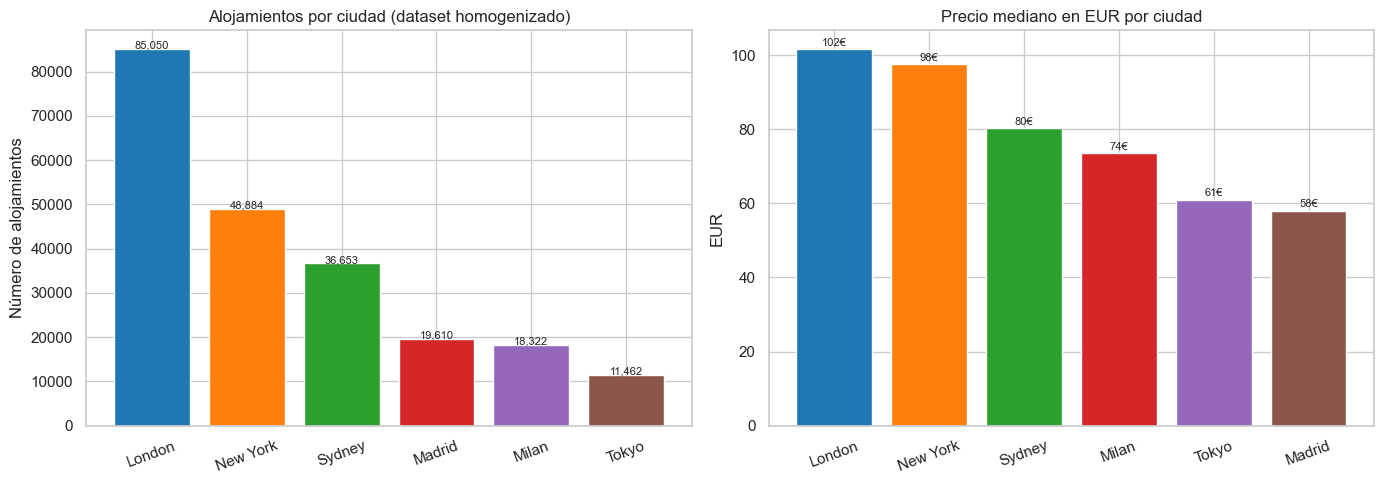


✅ Homogenización completada. Dataset listo para análisis.


In [16]:
# Resumen visual final
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Alojamientos por ciudad
conteo = df_homogenizado['city'].value_counts()
axes[0].bar(conteo.index, conteo.values, color=sns.color_palette('tab10', len(conteo)))
axes[0].set_title('Alojamientos por ciudad (dataset homogenizado)')
axes[0].set_ylabel('Número de alojamientos')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=8)

# Precio mediano en EUR por ciudad
precio_median = df_homogenizado.groupby('city')['price_eur'].median().sort_values(ascending=False)
axes[1].bar(precio_median.index, precio_median.values,
            color=sns.color_palette('tab10', len(precio_median)))
axes[1].set_title('Precio mediano en EUR por ciudad')
axes[1].set_ylabel('EUR')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(precio_median.values):
    axes[1].text(i, v + 1, f'{v:.0f}€', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print('\n✅ Homogenización completada. Dataset listo para análisis.')